# Machine Learning Model pipeline for RUL 

### NOTE: Before starting exploring this notebook, I strongly suggest checking the previous notebooks:

1-EDA.ipynb - contains some Exploratory Data Analysis of the datasets

2-target-metrics-baseline.ipynb - details about the target, evaluation metrics and a baseline model

3-features-engineering.ipynb - details about features engineering

Table of Contents:

1. Recap on the Baseline Model performance
2. Details about Cross-Validation and 3. 3
3. Testing
    1. Poisson Regression:
    2. with no features engineering
    3. with TSfresh features
4. NGBoost
    1. with TSfresh features.
    2. Performance on the Test set
    3. Prognostics Metrics
5. Model with ROCKET features

In [1]:
!jupyter nbconvert 3-features_engineering.ipynb --to script --output features_engineering --TagRemovePreprocessor.remove_cell_tags='{"remove"}'

C:\Users\amans\AppData\Roaming\Python\Python310\site-packages\traitlets\traitlets.py:2548: FutureWarning: Supporting extra quotes around strings is deprecated in traitlets 5.0. You can use 'remove' instead of "'remove'" if you require traitlets >=5.
  warn(
[NbConvertApp] Converting notebook 3-features_engineering.ipynb to script
[NbConvertApp] Writing 2990 bytes to features_engineering.py


In [2]:
! jupyter nbconvert 02_target_metric_baseline.ipynb \
    --to script \
    --TagRemovePreprocessor.remove_cell_tags='["remove"]' \
    --output target_metrics_baseline


C:\Users\amans\AppData\Roaming\Python\Python310\site-packages\traitlets\traitlets.py:2548: FutureWarning: Supporting extra quotes around strings is deprecated in traitlets 5.0. You can use '[remove]' instead of "'[remove]'" if you require traitlets >=5.
  warn(
[NbConvertApp] Converting notebook 02_target_metric_baseline.ipynb to script
[NbConvertApp] Writing 16459 bytes to target_metrics_baseline.py


In [3]:
! jupyter nbconvert 3-features_engineering.ipynb \
    --to script \
    --TagRemovePreprocessor.remove_cell_tags='["remove"]' \
    --output features_engineering


C:\Users\amans\AppData\Roaming\Python\Python310\site-packages\traitlets\traitlets.py:2548: FutureWarning: Supporting extra quotes around strings is deprecated in traitlets 5.0. You can use '[remove]' instead of "'[remove]'" if you require traitlets >=5.
  warn(
[NbConvertApp] Converting notebook 3-features_engineering.ipynb to script
[NbConvertApp] Writing 2990 bytes to features_engineering.py


In [4]:
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils2 import read_dataset

%matplotlib inline

In [ ]:
train, test, test_rul = read_dataset("FD001")

print("train:", train.shape)
print("test:", test.shape)
train.head(20)

train: (20631, 26)
test: (13096, 26)


,unit,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


### Baseline Model
As we saw in the 2-target-metrics-baseline.ipynb notebook, the baseline model scored the following values on the test set (FD001 dataset):

        {
            'rmse': 36.63836786757838,
            'mae': 31.37,
            'mape': 0.906682116160513,
            'score': 7657.158284814168
        }
Now we treat this as a reference for further experiments with models.

### Cross-validation and Testing
One important aspect in our cross-validation procedure is that the same engine will not appear in 2 different folds, meaning that a model can see some engine's all the data either during training or validation. For this kind of cross-validation we are using a scikit-learn method GroupKFold, where our groups are engines IDs. An example of cross-validation with sklearn.model_selection.GroupKFold 

### NOTE :
            As we saw in 2-target-metrics-baseline.ipynb notebook, distributions of train and test Remaining Useful Life differ, which might lead to cross-validation results not aligning well with performance on the test set. We try to alter validation sets to limit its ranges according to the test set:

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_validate

In [ ]:
class CustomGroupKFold(GroupKFold):
    """
    Cross validation splitter which drops validation records with RUL values outside of test set RUL ranges.


    """

    def split(self, X, y, groups):
        splits = super.split(X, y, groups)
        for train_ind, val_ind in splits:
            yield train_ind, val_ind[(y[val_ind] > 6) & (y[val_ind] < 125)]

In [ ]:
def evaluate(
    model,
    X,
    y,
    groups,
    cv,
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error"],
    n_jobs=None,
    verbose=False,
):
    """
    Evaluate a model with Cross-Validation
    """
    cv_results = cross_validate(
        model,
        X=X,
        y=y,
        groups=groups,
        scoring=scoring,
        cv=cv,
        return_train_score=True,
        return_estimator=True,
        n_jobs=n_jobs,
        verbose=verbose,
    )

    for k, v in cv_results.items():
        if k.startswith("train_") or k.startswith("test_"):
            k_sp = k.split("_")
            print(
                f'[{k_sp[0]}] :: {" ".join(k_sp[2:])} : {np.abs(v.mean()):.2f} +- {v.std():.2f}'
            )
    return cv_results

### When testing model on a test set, we treat the model's prediction on the last available time step as a final prediction. The function below evaluates a model on a test set comparing the last predictions from every engine with the true RUL values:

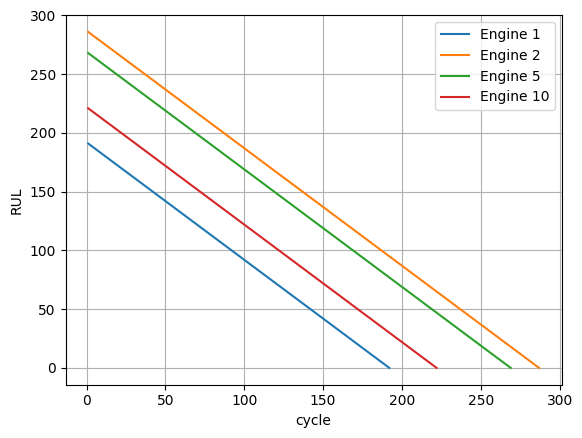

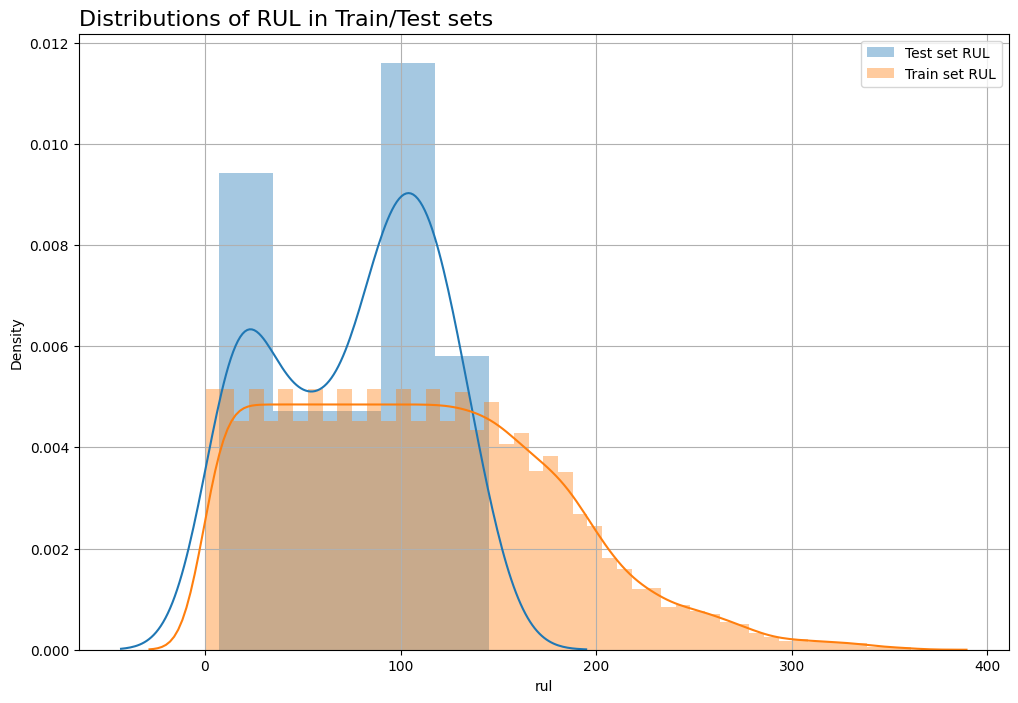

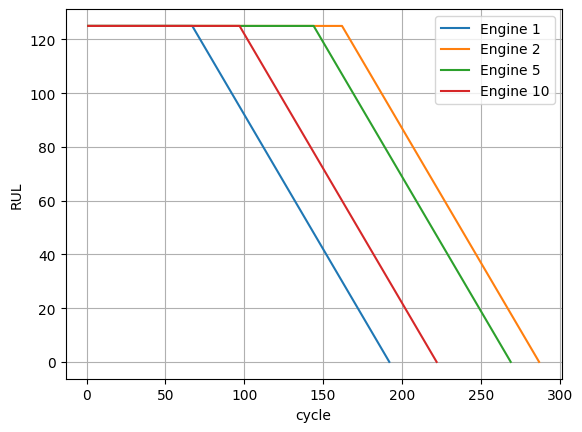

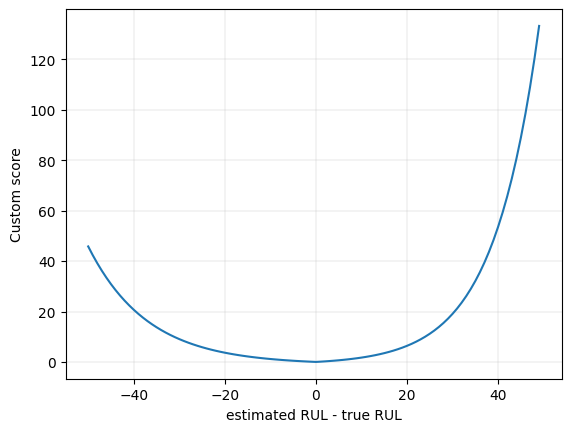

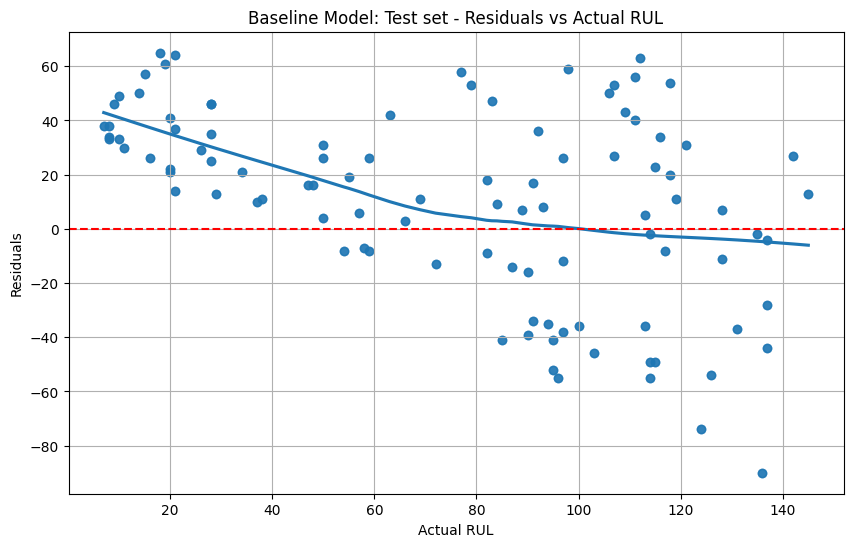

In [9]:
from target_metrics_baseline import plot_residuals_vs_actual
from target_metrics_baseline import rul_metrics_scorer

In [ ]:
def test_model(model, X_test, engines, test_rul, plot_figures=False, **plot_kwargs):
    """
    Evaluate on a test set.
    """
    X_test_last = X_test.groupby(engines, as_index=False).last()
    if plot_figures:
        pred_rul = model.predict(X_test_last.values)
        plot_residuals_vs_actual(test_rul, pred_rul, **plot_kwargs)

    return rul_metrics_scorer(model, X_test_last.values, test_rul, metrics="all")

## Linear Model
We would like to start with a simple model using the original data without features engineering, that should also give us some reference for further modeling.

A couple of important comments here:

1. our targets are non-negative integers

2. models that assume normal distribution of target, e.g. linear regression, can output negative predictions.

3. if use such models, you have to transform your target - for instance, log transform and inverse transform with exponential (we'll do that later in section with ROCKET features)
4. our observations are not independent of each other

Poisson regression might be a good option here. First we train the model on the original data:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.compose import make_column_selector
from target_metrics_baseline import calculate_RUL

In [ ]:
RUL_THRESHOLD = 125

In [ ]:
from sklearn.model_selection import GroupKFold


class CustomGroupKFold(GroupKFold):
    def split(self, X, y=None, groups=None):
        # use parent GroupKFold split
        splits = super().split(X, y, groups)

        for train_idx, val_idx in splits:
            # filter validation samples by RUL condition
            mask = (y[val_idx] > 6) & (y[val_idx] < 125)
            yield train_idx, val_idx[mask]

In [ ]:
get_ftr_names = make_column_selector(pattern="sensor")

model = Pipeline([("scale", StandardScaler()), ("model", PoissonRegressor(alpha=0.1))])

cv_result = evaluate(
    model,
    X=train[get_ftr_names(train)].values,
    y=calculate_RUL(train, upper_threshold=RUL_THRESHOLD),
    groups=train["unit"],
    cv=CustomGroupKFold(n_splits=5),
)

[test] :: root mean squared error : 21.36 +- 1.54
[train] :: root mean squared error : 23.91 +- 0.30
[test] :: mean absolute error : 17.03 +- 1.87
[train] :: mean absolute error : 19.49 +- 0.36


In [15]:
# Now we would like to apply our preprocessing steps and try the same model:

In [16]:
from features_engineering import LowVarianceFeaturesRemover, ScalePerEngine
from utils2 import SENSOR_COLUMNS

train.shape = (20631, 27)


In [ ]:
preprocess_pipe = Pipeline(
    [
        # Cleaning constant features
        ("drop-low-variance", LowVarianceFeaturesRemover(threshold=0)),
        # Scaling sensors values
        (
            "scale-per-engine",
            ScalePerEngine(n_first_cycles=15, sensors_columns=SENSOR_COLUMNS),
        ),
    ]
)

train_sc = preprocess_pipe.fit_transform(train)

Droped low variance features: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [ ]:
model = Pipeline([("scale", StandardScaler()), ("model", PoissonRegressor(alpha=0.1))])

cv_result = evaluate(
    model,
    X=train_sc[get_ftr_names(train_sc)].values,
    y=calculate_RUL(train_sc, upper_threshold=RUL_THRESHOLD),
    groups=train_sc["unit"],
    cv=CustomGroupKFold(n_splits=5),
)

[test] :: root mean squared error : 17.66 +- 0.75
[train] :: root mean squared error : 18.07 +- 0.12
[test] :: mean absolute error : 13.86 +- 0.49
[train] :: mean absolute error : 14.22 +- 0.08


## Poisson Regression with TSfresh Features
Here we use the features engineering pipeline we've prepared in 3-features_engineering.ipynb notebook.

We would like to incorporate features values from both long and short time ranges. There're two pipelines:

1. the first one aggregates data into windows of length 20, calculates PCA on top of TSFresh features and select top components.

2. the other pipeline aggregates data into windows of length 5, and calculates averages

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold
from tsfresh.utilities.dataframe_functions import roll_time_series


class RollTimeSeries(BaseEstimator, TransformerMixin):
    def __init__(self, min_timeshift, max_timeshift, rolling_direction):
        self.min_timeshift = min_timeshift
        self.max_timeshift = max_timeshift
        self.rolling_direction = rolling_direction

    def fit(self, X):
        return self

    def transform(self, X):
        _start = datetime.now()
        print("Start Rolling TS")
        X_t = roll_time_series(
            X,
            column_id="unit",
            column_sort="time_cycles",
            rolling_direction=self.rolling_direction,
            min_timeshift=self.min_timeshift,
            max_timeshift=self.max_timeshift,
        )
        print(f"Done Rolling TS in {datetime.now() - _start}")
        return X_t

In [ ]:
tsfresh_calc = {
    "mean_change": None,
    "mean": None,
    "standard_deviation": None,
    "root_mean_square": None,
    "last_location_of_maximum": None,
    "first_location_of_maximum": None,
    "last_location_of_minimum": None,
    "first_location_of_minimum": None,
    "maximum": None,
    "minimum": None,
    "time_reversal_asymmetry_statistic": [{"lag": 1}, {"lag": 2}, {"lag": 3}],
    "c3": [{"lag": 1}, {"lag": 2}, {"lag": 3}],
    "cid_ce": [{"normalize": True}, {"normalize": False}],
    "autocorrelation": [
        {"lag": 0},
        {"lag": 1},
        {"lag": 2},
        {"lag": 3},
    ],
    "partial_autocorrelation": [
        {"lag": 0},
        {"lag": 1},
        {"lag": 2},
        {"lag": 3},
    ],
    "linear_trend": [{"attr": "intercept"}, {"attr": "slope"}, {"attr": "stderr"}],
    "augmented_dickey_fuller": [
        {"attr": "teststat"},
        {"attr": "pvalue"},
        {"attr": "usedlag"},
    ],
    "linear_trend_timewise": [{"attr": "intercept"}, {"attr": "slope"}],
    "lempel_ziv_complexity": [
        {"bins": 2},
        {"bins": 3},
        {"bins": 5},
        {"bins": 10},
        {"bins": 100},
    ],
    "permutation_entropy": [
        {"tau": 1, "dimension": 3},
        {"tau": 1, "dimension": 4},
        {"tau": 1, "dimension": 5},
        {"tau": 1, "dimension": 6},
        {"tau": 1, "dimension": 7},
    ],
    "fft_coefficient": [
        {"coeff": 0, "attr": "abs"},
        {"coeff": 1, "attr": "abs"},
        {"coeff": 2, "attr": "abs"},
        {"coeff": 3, "attr": "abs"},
        {"coeff": 4, "attr": "abs"},
        {"coeff": 5, "attr": "abs"},
        {"coeff": 6, "attr": "abs"},
        {"coeff": 7, "attr": "abs"},
        {"coeff": 8, "attr": "abs"},
        {"coeff": 9, "attr": "abs"},
        {"coeff": 10, "attr": "abs"},
    ],
    "fft_aggregated": [
        {"aggtype": "centroid"},
        {"aggtype": "variance"},
        {"aggtype": "skew"},
        {"aggtype": "kurtosis"},
    ],
}

In [ ]:
from tsfresh import extract_features, select_features
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from utils2 import calculate_RUL, SENSOR_COLUMNS


class TSFreshFeaturesExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, calc=tsfresh_calc):
        self.calc = calc

    def _clean_features(self, X):
        old_shape = X.shape
        X_t = X.T.drop_duplicates().T
        print(f"Droped {old_shape[1] - X_t.shape[1]} duplicate features")

        old_shape = X_t.shape
        X_t = X_t.dropna(axis=1)
        print(f"Droped {old_shape[1] - X_t.shape[1]} features with NA values")
        return X_t

    def fit(self, X):
        return self

    def transform(self, X):
        _start = datetime.now()
        print("Start Extracting Features")
        X_t = extract_features(
            X[
                ["id", "time_cycles"]
                + X.columns[X.columns.str.startswith("sensor")].tolist()
            ],
            column_id="id",
            column_sort="time_cycles",
            default_fc_parameters=self.calc,
        )
        print(f"Done Extracting Features in {datetime.now() - _start}")
        X_t = self._clean_features(X_t)
        return X_t


class CustomPCA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=None, random_state=None):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X):
        assert "unit" not in X.columns, "columns should be only features"
        self.ftr_columns = X.columns

        self.scaler = StandardScaler()
        X_sc = self.scaler.fit_transform(X[self.ftr_columns].values)

        self.pca = PCA(n_components=self.n_components, random_state=self.random_state)
        self.pca.fit_transform(X_sc)
        return self

    def transform(self, X):
        X_sc = self.scaler.transform(X[self.ftr_columns].values)
        X_pca = self.pca.transform(X_sc)
        return pd.DataFrame(X_pca, index=X.index)


class TSFreshFeaturesSelector(BaseEstimator, TransformerMixin):
    def __init__(self, fdr_level=0.001):
        self.fdr_level = fdr_level

    def fit(self, X):
        rul = calculate_RUL(
            X.index.to_frame(name=["unit", "time_cycles"]).reset_index(drop=True),
            upper_threshold=135,
        )

        X_t = select_features(X, rul, fdr_level=self.fdr_level)
        self.selected_ftr = X_t.columns

        print(
            f"Selected {len(self.selected_ftr)} out of {X.shape[1]} features: "
            f"{self.selected_ftr.to_list()}"
        )
        return self

    def transform(self, X):
        return X[self.selected_ftr]

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
features_long_h_pipe = Pipeline(
    [
        # Cleaning
        ("drop-low-variance", LowVarianceFeaturesRemover(threshold=0)),
        # Scaling and Preprocessing
        (
            "scale-per-engine",
            ScalePerEngine(n_first_cycles=10, sensors_columns=SENSOR_COLUMNS),
        ),
        (
            "roll-time-series",
            RollTimeSeries(min_timeshift=19, max_timeshift=19, rolling_direction=1),
        ),
        # TSFresh features engineering
        ("extract-tsfresh-features", TSFreshFeaturesExtractor(calc=tsfresh_calc)),
        ("PCA", CustomPCA(n_components=20)),
        ("features-selection", TSFreshFeaturesSelector(fdr_level=0.001)),
    ]
)


features_short_h_pipe = Pipeline(
    [
        # Cleaning
        ("drop-low-variance", LowVarianceFeaturesRemover(threshold=0)),
        # Scaling and Preprocessing
        (
            "scale-per-engine",
            ScalePerEngine(n_first_cycles=10, sensors_columns=SENSOR_COLUMNS),
        ),
        (
            "roll-time-series",
            RollTimeSeries(min_timeshift=4, max_timeshift=4, rolling_direction=1),
        ),
        # TSFresh features engineering
        ("extract-tsfresh-features", TSFreshFeaturesExtractor(calc={"mean": None})),
        ("features-selection", TSFreshFeaturesSelector(fdr_level=0.0002)),
    ]
)

In [24]:
train

,unit,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [25]:
train_long_h_ftrs = features_long_h_pipe.fit_transform(train)

Droped low variance features: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Start Rolling TS


Rolling: 100%|██████████| 30/30 [00:24<00:00,  1.23it/s]


Done Rolling TS in 0:00:24.994980
Start Extracting Features


Feature Extraction: 100%|██████████| 30/30 [11:10<00:00, 22.35s/it]  


Done Extracting Features in 0:11:46.567032
Droped 19 duplicate features
Droped 14 features with NA values
Selected 10 out of 20 features: [0, 2, 3, 4, 1, 5, 6, 15, 8, 7]


In [33]:
train_long_h_ftrs

0         2         3         4          1         5   \
1.0   30.0   -9.624627 -1.375857  5.202666 -0.056590  -1.198654  1.000783   
      31.0   -9.610012 -1.235646  5.143077 -0.186984  -1.076462  2.196077   
      32.0  -10.311811 -1.304122  5.208885  1.296712  -0.889627  1.452251   
      33.0  -10.138647 -0.869974  5.485206  0.981340  -0.960259  1.002167   
      34.0   -9.202262 -1.103085  4.947814  0.442484  -0.754631  0.081335   
...                ...       ...       ...       ...        ...       ...   
100.0 196.0  27.937675  1.592452  1.488659 -0.158088 -12.338241  1.541469   
      197.0  28.251130  1.341939  0.831921  1.483090 -12.081224  1.734813   
      198.0  30.316222  2.449101  1.895989  2.950258 -12.149074  1.483449   
      199.0  32.061710  3.056459  2.773959  3.431950 -11.940523  1.028125   
      200.0  32.824864  3.275056  3.182155  3.836367 -13.054522  0.976347   

                   6         15        8         7   
1.0   30.0   0.494852 -1.121093 -1.937569  4.042523  
      31.0   0.538493 -1.379848 -2.035988  3.007772  
      32.0  -0.226402 -2.504948 -2.286508  2.487153  
      33.0  -0.184966 -2.798829 -2.905607  4.128751  
      34.0   0.025408 -2.242204 -3.919636  4.522258  
...               ...       ...       ...       ...  
100.0 196.0  2.514684  1.346363 -2.003072  1.278009  
      197.0  3.672411  0.339030 -3.134532  1.157811  
      198.0  4.554734 -0.194295 -2.522286  2.679600  
      199.0  5.150968 -0.647766 -2.167812  2.926159  
      200.0  5.394725 -2.053300 -1.930107  3.291617  

[17731 rows x 10 columns]

In [36]:
train_long_h_ftrs.describe()

,0,2,3,4,1,5,6,15,8,7
count,1.773100e+04,1.773100e+04,1.773100e+04,1.773100e+04,1.773100e+04,1.773100e+04,1.773100e+04,1.773100e+04,1.773100e+04,1.773100e+04
mean,1.282351e-16,3.526466e-16,-2.179997e-16,5.129404e-17,1.634998e-16,5.129404e-17,1.282351e-17,-1.923527e-17,7.694107e-17,-1.154116e-16
std,1.208913e+01,4.522464e+00,3.665355e+00,2.946770e+00,6.019315e+00,2.598062e+00,2.594938e+00,2.221918e+00,2.397248e+00,2.454317e+00
min,-1.278849e+01,-4.725989e+00,-9.506932e+00,-4.400526e+01,-2.765169e+01,-9.981761e+00,-1.570996e+01,-7.953892e+00,-1.049488e+01,-8.948142e+00
25%,-8.298662e+00,-3.050107e+00,-2.630512e+00,-1.555943e+00,-1.871602e+00,-1.537782e+00,-1.587911e+00,-1.503181e+00,-1.575019e+00,-1.642225e+00
50%,-4.780315e+00,-2.025146e+00,-4.662968e-01,7.413491e-02,-5.588280e-01,-4.684919e-02,7.846775e-02,-2.687841e-02,9.373222e-03,-9.915235e-03
75%,4.088945e+00,1.781400e+00,2.696737e+00,1.516204e+00,8.165419e-01,1.389923e+00,1.726663e+00,1.473166e+00,1.523777e+00,1.659918e+00
max,7.208310e+01,2.782547e+01,4.700064e+01,2.686451e+01,5.739675e+01,1.803323e+01,9.705623e+00,1.315311e+01,1.076631e+01,9.248768e+00


In [37]:
train_short_h_ftr = features_short_h_pipe.fit_transform(train)

Droped low variance features: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Start Rolling TS


Rolling: 100%|██████████| 30/30 [00:19<00:00,  1.55it/s]


Done Rolling TS in 0:00:19.885286
Start Extracting Features


Feature Extraction: 100%|██████████| 30/30 [00:49<00:00,  1.66s/it]


Done Extracting Features in 0:00:50.765284
Droped 0 duplicate features
Droped 0 features with NA values
Selected 15 out of 15 features: ['sensor_2__mean', 'sensor_3__mean', 'sensor_4__mean', 'sensor_7__mean', 'sensor_9__mean', 'sensor_8__mean', 'sensor_11__mean', 'sensor_12__mean', 'sensor_21__mean', 'sensor_13__mean', 'sensor_15__mean', 'sensor_17__mean', 'sensor_20__mean', 'sensor_14__mean', 'sensor_6__mean']


In [38]:
train_short_h_ftr

sensor_2__mean  sensor_3__mean  sensor_4__mean  sensor_7__mean  \
1.0   15.0            0.237          -2.888          -0.258           0.028   
      16.0            0.207          -1.642           0.514          -0.092   
      17.0            0.311          -1.332           0.474          -0.236   
      18.0            0.221           0.438          -0.468          -0.084   
      19.0            0.109          -0.640          -0.230          -0.144   
...                     ...             ...             ...             ...   
100.0 196.0           0.991           9.923          25.466          -2.306   
      197.0           0.993          10.577          28.286          -2.362   
      198.0           1.059          11.107          28.136          -2.582   
      199.0           0.961          12.701          27.960          -2.844   
      200.0           1.049          12.769          28.008          -2.970   

             sensor_9__mean  sensor_8__mean  sensor_11__mean  sensor_12__mean  \
1.0   15.0           -0.482           0.043            0.018           -0.302   
      16.0           -0.536           0.043            0.036           -0.284   
      17.0            0.574           0.037            0.024           -0.266   
      18.0            1.120           0.023           -0.010           -0.284   
      19.0            2.444           0.013           -0.018           -0.240   
...                     ...             ...              ...              ...   
100.0 196.0           7.523           0.160            0.750           -1.988   
      197.0           8.455           0.172            0.722           -2.170   
      198.0           8.121           0.162            0.702           -2.190   
      199.0           9.095           0.166            0.756           -2.166   
      200.0           7.453           0.172            0.752           -2.248   

             sensor_21__mean  sensor_13__mean  sensor_15__mean  \
1.0   15.0          -0.01900           -0.006          0.00347   
      16.0          -0.02374            0.006         -0.00461   
      17.0          -0.03056            0.010          0.00747   
      18.0          -0.00596            0.008          0.00499   
      19.0          -0.01320            0.014          0.01213   
...                      ...              ...              ...   
100.0 196.0         -0.23303            0.163          0.10170   
      197.0         -0.21655            0.165          0.10664   
      198.0         -0.23449            0.175          0.11108   
      199.0         -0.24817            0.177          0.11456   
      200.0         -0.27619            0.173          0.10490   

             sensor_17__mean  sensor_20__mean  sensor_14__mean  sensor_6__mean  
1.0   15.0               0.2            0.036            0.756           0.000  
      16.0               0.2            0.042           -0.138           0.000  
      17.0               0.4           -0.008            0.466           0.000  
      18.0               0.2           -0.016            1.392           0.000  
      19.0              -0.2           -0.092            0.332           0.000  
...                      ...              ...              ...             ...  
100.0 196.0              3.4           -0.547           -1.649           0.001  
      197.0              3.0           -0.599           -3.041           0.001  
      198.0              3.2           -0.605           -3.235           0.001  
      199.0              3.4           -0.623           -3.311           0.001  
      200.0              3.8           -0.577           -4.425           0.001  

[19231 rows x 15 columns]

In [ ]:
train_ftrs = train_long_h_ftrs.merge(
    train_short_h_ftr, how="inner", right_index=True, left_index=True
)

train_ftrs.index = train_ftrs.index.set_names(["unit", "time_cycles"])

print("train_ftrs : ", train_ftrs.shape)
train_ftrs

train_ftrs :  (17731, 25)


0         2         3         4          1  \
unit  time_cycles                                                       
1.0   30.0         -9.624627 -1.375857  5.202666 -0.056590  -1.198654   
      31.0         -9.610012 -1.235646  5.143077 -0.186984  -1.076462   
      32.0        -10.311811 -1.304122  5.208885  1.296712  -0.889627   
      33.0        -10.138647 -0.869974  5.485206  0.981340  -0.960259   
      34.0         -9.202262 -1.103085  4.947814  0.442484  -0.754631   
...                      ...       ...       ...       ...        ...   
100.0 196.0        27.937675  1.592452  1.488659 -0.158088 -12.338241   
      197.0        28.251130  1.341939  0.831921  1.483090 -12.081224   
      198.0        30.316222  2.449101  1.895989  2.950258 -12.149074   
      199.0        32.061710  3.056459  2.773959  3.431950 -11.940523   
      200.0        32.824864  3.275056  3.182155  3.836367 -13.054522   

                          5         6        15         8         7  ...  \
unit  time_cycles                                                    ...   
1.0   30.0         1.000783  0.494852 -1.121093 -1.937569  4.042523  ...   
      31.0         2.196077  0.538493 -1.379848 -2.035988  3.007772  ...   
      32.0         1.452251 -0.226402 -2.504948 -2.286508  2.487153  ...   
      33.0         1.002167 -0.184966 -2.798829 -2.905607  4.128751  ...   
      34.0         0.081335  0.025408 -2.242204 -3.919636  4.522258  ...   
...                     ...       ...       ...       ...       ...  ...   
100.0 196.0        1.541469  2.514684  1.346363 -2.003072  1.278009  ...   
      197.0        1.734813  3.672411  0.339030 -3.134532  1.157811  ...   
      198.0        1.483449  4.554734 -0.194295 -2.522286  2.679600  ...   
      199.0        1.028125  5.150968 -0.647766 -2.167812  2.926159  ...   
      200.0        0.976347  5.394725 -2.053300 -1.930107  3.291617  ...   

                   sensor_8__mean  sensor_11__mean  sensor_12__mean  \
unit  time_cycles                                                     
1.0   30.0                  0.017            0.064            0.144   
      31.0                  0.019            0.094            0.078   
      32.0                  0.023            0.070            0.062   
      33.0                  0.007            0.044           -0.070   
      34.0                  0.003            0.090           -0.212   
...                           ...              ...              ...   
100.0 196.0                 0.160            0.750           -1.988   
      197.0                 0.172            0.722           -2.170   
      198.0                 0.162            0.702           -2.190   
      199.0                 0.166            0.756           -2.166   
      200.0                 0.172            0.752           -2.248   

                   sensor_21__mean  sensor_13__mean  sensor_15__mean  \
unit  time_cycles                                                      
1.0   30.0                -0.00622            0.022          0.00927   
      31.0                -0.02214            0.022          0.00615   
      32.0                -0.01160            0.010          0.00819   
      33.0                 0.00170            0.010         -0.00321   
      34.0                -0.00840            0.016         -0.00001   
...                            ...              ...              ...   
100.0 196.0               -0.23303            0.163          0.10170   
      197.0               -0.21655            0.165          0.10664   
      198.0               -0.23449            0.175          0.11108   
      199.0               -0.24817            0.177          0.11456   
      200.0               -0.27619            0.173          0.10490   

                   sensor_17__mean  sensor_20__mean  sensor_14__mean  \
unit  time_cycles                                                      
1.0   30.0            2.000000e-01    -1.600000e-02            0.566   
      31.0 

In [ ]:
X_train = train_ftrs.reset_index().drop(columns=["unit"])

train_units_df = train_ftrs.index.to_frame(index=False)
y_train = calculate_RUL(train_units_df, upper_threshold=RUL_THRESHOLD)

In [ ]:
model = Pipeline([("scale", StandardScaler()), ("model", PoissonRegressor(alpha=0.01))])

cv_res = evaluate(
    model,
    X=X_train.values,
    y=y_train,
    groups=train_units_df["unit"],
    cv=CustomGroupKFold(n_splits=5),
)

[test] :: root mean squared error : 12.65 +- 1.12
[train] :: root mean squared error : 12.71 +- 0.18
[test] :: mean absolute error : 10.04 +- 0.85
[train] :: mean absolute error : 10.08 +- 0.15


### Observations:
        So, our features engineering pipeline significantly improves the model's performance - RMSE 12.65 vs 19.18 (from the previous experiment).

### NGBoost - Natural Gradient Boosting for Probabilistic Prediction
    A problem of single point predictions is that it provides no uncertainty estimates of a given prediction. Usually, in real world use cases, uncetainties assosiated with a provided predictions might be of more importance then the predictions itself. There's a good example of problems that can happen when not considering this, in book of Nate Silver "The Signal and the Noise: Why So Many Predictions Fail-but Some Don't".

So, we would like to focus on methods able to provide prediction intervals.

    NGBoost - an interesting algorithm which provides predictive uncertainty estimation to gradient boosting:

        https://stanfordmlgroup.github.io/projects/ngboost/

NGBoost model outputs a full probability distribution over the entire outcome space.



In [45]:
from ngboost import NGBRegressor
from ngboost.distns import LogNormal, Poisson

In [46]:
ngb = NGBRegressor(Dist=Poisson)

cv_res = evaluate(
    ngb,
    X=X_train.values,
    y=y_train,
    groups=train_units_df["unit"],
    cv=CustomGroupKFold(n_splits=4),
    n_jobs=5,
)

[test] :: root mean squared error : 12.43 +- 0.31
[train] :: root mean squared error : 10.77 +- 0.04
[test] :: mean absolute error : 9.43 +- 0.31
[train] :: mean absolute error : 8.24 +- 0.02


### Observation:

        With NGBRegressor we obtained a slightly better mean absolute error .

        we'ld like to do a small hyperparameter search, trying a base learner, minibatch fraction and ratio of features to sample.

In [47]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

In [48]:
param_grid = {
    "Base": [
        DecisionTreeRegressor(criterion="friedman_mse", max_depth=4),
        DecisionTreeRegressor(
            criterion="friedman_mse",
            max_depth=5,
            max_features=0.8,
            min_samples_split=80,
        ),
    ],
    "minibatch_frac": [1, 0.8, 0.5, 0.25],
}

ngb = NGBRegressor(Dist=Poisson, learning_rate=0.001, n_estimators=500, verbose=False)

grid_search_cv = GridSearchCV(
    ngb,
    scoring="neg_root_mean_squared_error",
    param_grid=param_grid,
    cv=CustomGroupKFold(n_splits=5),
    n_jobs=6,
)

## excluding 0 RUL values seems to do better

grid_search_cv.fit(
    X_train[y_train > 0].values,
    y_train[y_train > 0],
    groups=train_units_df[y_train > 0]["unit"],
)

,estimator,NGBRegressor(...verbose=False)
,param_grid,"{'Base': [DecisionTreeR..., max_depth=4), DecisionTreeR...ples_split=80)], 'minibatch_frac': [1, 0.8, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,6
,refit,True
,cv,CustomGroupKF...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [49]:
ngb_base = DecisionTreeRegressor(
    criterion="friedman_mse",
    max_depth=5,
    max_features=0.8,
    min_samples_leaf=50,
    min_samples_split=80,
)

ngb = NGBRegressor(
    Dist=Poisson,
    Base=ngb_base,
    learning_rate=0.01,
    col_sample=0.8,
    minibatch_frac=0.5,
    n_estimators=500,
)

cv_res = evaluate(
    ngb,
    X=X_train[y_train > 0].values,
    y=y_train[y_train > 0],
    groups=train_units_df[y_train > 0]["unit"],
    cv=CustomGroupKFold(n_splits=5),
    n_jobs=6,
)

[test] :: root mean squared error : 11.58 +- 1.01
[train] :: root mean squared error : 8.63 +- 0.12
[test] :: mean absolute error : 8.79 +- 0.98
[train] :: mean absolute error : 6.21 +- 0.12


### Observation:

    Wee see a slight improovement in both of our metric scores.
    mean absolute error decreased by ~2 as compared to Base Learner as well as mean squared error came down from 12 to 11.58 .


We can now check the features importances - let's consider average of features importances from cross-validation iterations: 

In [53]:
for i, cv_estimator in enumerate(cv_res["estimator"]):
    df = pd.DataFrame(
        {
            "cv_iter": [i] * len(X_train.columns),
            "feature": X_train.columns,
            "importance": cv_estimator.feature_importances_.reshape(-1).round(5),
        }
    )
    ftr_importance = pd.concat([ftr_importance, df], ignore_index=True)

ftr_importance_agg = (
    ftr_importance.groupby("feature")["importance"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

ftr_importance_agg

,feature,mean,std
0,0,0.267774,0.010712
1,sensor_4__mean,0.098650,0.009117
2,sensor_11__mean,0.080856,0.020912
3,time_cycles,0.068108,0.003538
4,sensor_15__mean,0.066502,0.021316
5,sensor_6__mean,0.048518,0.004439
6,sensor_21__mean,0.039384,0.013375
7,sensor_9__mean,0.033862,0.001730
8,3,0.024886,0.004302
9,sensor_14__mean,0.024378,0.005911


### NOTE: 
    As expected, the first principal component from tsfresh features calculated on a longer cycles window got the highest importance with a big gap from the next less important feature. However, all the rest principal components seem to be of little importance

In [54]:
drop_features = ftr_importance_agg["feature"].iloc[-6:].values
drop_features

array(['sensor_12__mean', 15, 'sensor_8__mean', 'sensor_2__mean',
       'sensor_13__mean', 'sensor_17__mean'], dtype=object)

In [55]:
SELECTED_FEATURES = ftr_importance_agg["feature"].iloc[:-6].values
SELECTED_FEATURES

array([0, 'sensor_4__mean', 'sensor_11__mean', 'time_cycles',
       'sensor_15__mean', 'sensor_6__mean', 'sensor_21__mean',
       'sensor_9__mean', 3, 'sensor_14__mean', 'sensor_20__mean', 2, 1, 8,
       4, 'sensor_3__mean', 6, 'sensor_7__mean', 5, 7], dtype=object)

In [56]:
ngb_base = DecisionTreeRegressor(
    criterion="friedman_mse", max_depth=5, max_features=0.8, min_samples_leaf=50
)
ngb = NGBRegressor(
    Dist=Poisson,
    Base=ngb_base,
    learning_rate=0.01,
    col_sample=0.8,
    minibatch_frac=0.5,
    n_estimators=400,
    verbose=False,
)

cv_res = evaluate(
    ngb,
    X=X_train[SELECTED_FEATURES][y_train > 0].values,
    y=y_train[y_train > 0],
    groups=train_units_df[y_train > 0]["unit"],
    cv=CustomGroupKFold(n_splits=4),
    n_jobs=4,
)

[test] :: root mean squared error : 11.85 +- 0.13
[train] :: root mean squared error : 8.84 +- 0.13
[test] :: mean absolute error : 8.90 +- 0.12
[train] :: mean absolute error : 6.40 +- 0.09


### Observation:
        Evaluate on a test set Before testing the model on a corresponding test set - we train the model on a whole train set:

In [57]:
ngb.fit(X_train[SELECTED_FEATURES][y_train > 0].values, y_train[y_train > 0])

,Dist,<class 'ngboo...sson.Poisson'>
,Score,<class 'ngboo...res.LogScore'>
,Base,DecisionTreeR...mples_leaf=50)
,natural_gradient,True
,n_estimators,400
,learning_rate,0.01
,minibatch_frac,0.5
,col_sample,0.8
,verbose,False
,random_state,RandomState(M... 0x2347F16E940
,validation_fraction,0.1


In [59]:
test_long_h_fts = features_long_h_pipe.transform(test)
test_short_h_fts = features_short_h_pipe.transform(test)

test_ftrs = test_long_h_fts.merge(
    test_short_h_fts, how="inner", right_index=True, left_index=True
)
test_ftrs.index = test_ftrs.index.set_names(["unit", "time_cycles"])

X_test = test_ftrs.reset_index().drop(columns=["unit"])
test_units = test_ftrs.index.to_frame(index=False)

print("test_ftrs: ", test_ftrs.shape)

Droped low variance features: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Start Rolling TS


Rolling: 100%|██████████| 30/30 [00:08<00:00,  3.50it/s]


Done Rolling TS in 0:00:09.036328
Start Extracting Features


Feature Extraction: 100%|██████████| 30/30 [03:02<00:00,  6.07s/it]


Done Extracting Features in 0:03:21.620135
Droped 19 duplicate features
Droped 14 features with NA values
Droped low variance features: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Start Rolling TS


Rolling: 100%|██████████| 30/30 [00:07<00:00,  3.79it/s]


Done Rolling TS in 0:00:08.300606
Start Extracting Features


Feature Extraction: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


Done Extracting Features in 0:00:23.439624
Droped 0 duplicate features
Droped 0 features with NA values
test_ftrs:  (10196, 25)


{'rmse': np.float64(12.206239849149396),
 'mae': 9.364359251084464,
 'mape': 0.16763503575071717,
 'score': np.float64(227.71390748081836)}

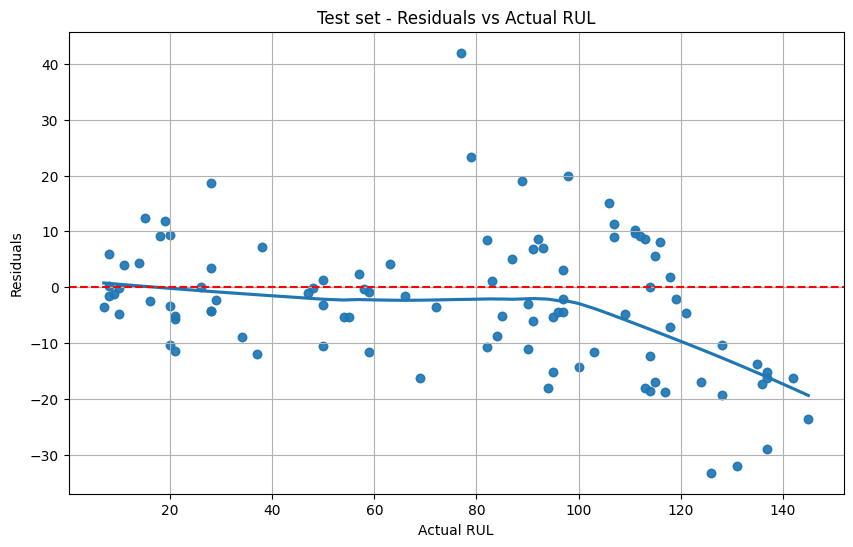

In [60]:
test_model(
    ngb, X_test[SELECTED_FEATURES], test_units["unit"], test_rul, plot_figures=True
)

### Observation:
        Looks good, except the right side, where engines with the highest actual RUL - the model underestimates their Remaining Useful Life.

## Prognostics Metrics
    Let's also evaluate the model with the prognostics metrics described in 2-target-metrics-baseline.ipynb.

We sample 10 engines for validation set to be evaluated with the prognostics metrics, and we retrain the model on all the rest engines data.

In [61]:
np.random.seed(2025)
validation_units = np.random.choice(
    train_units_df["unit"].unique(), size=10, replace=False
)
validation_units

array([50., 78., 62., 70.,  7., 96., 69., 20.,  3.,  6.])

In [63]:
X_train_sample = X_train[~train_units_df["unit"].isin(validation_units)]
y_train_sample = y_train[~train_units_df["unit"].isin(validation_units)]

ngb = NGBRegressor(
    Dist=Poisson,
    Base=ngb_base,
    learning_rate=0.01,
    col_sample=0.8,
    minibatch_frac=0.5,
    n_estimators=400,
    verbose=False,
)
ngb.fit(
    X_train_sample[SELECTED_FEATURES][y_train_sample > 0].values,
    y_train_sample[y_train_sample > 0],
)

,Dist,<class 'ngboo...sson.Poisson'>
,Score,<class 'ngboo...res.LogScore'>
,Base,DecisionTreeR...mples_leaf=50)
,natural_gradient,True
,n_estimators,400
,learning_rate,0.01
,minibatch_frac,0.5
,col_sample,0.8
,verbose,False
,random_state,RandomState(M... 0x2347F16E940
,validation_fraction,0.1


In [64]:
from target_metrics_baseline import (
    prognostic_horizon,
    alpha_lambda_acc,
    relative_accuracy,
)

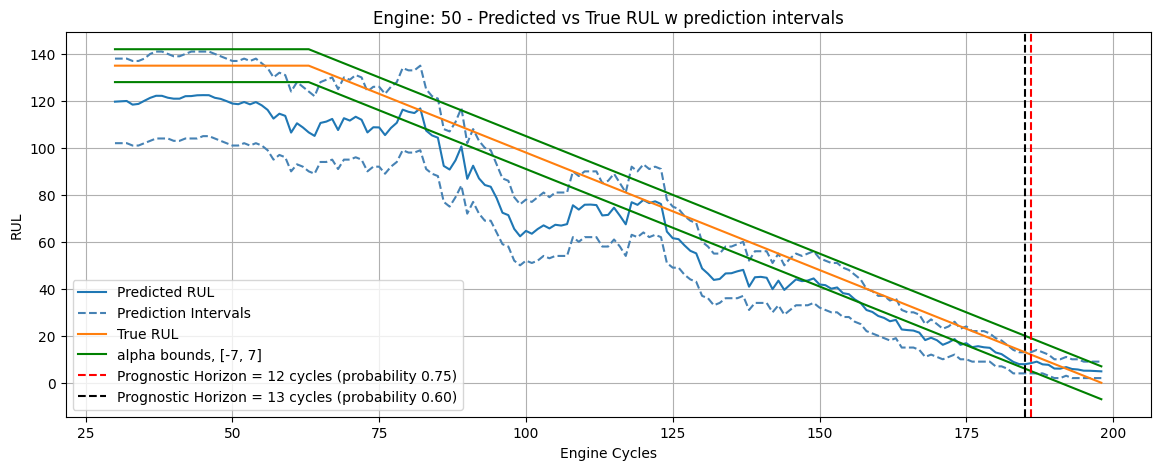

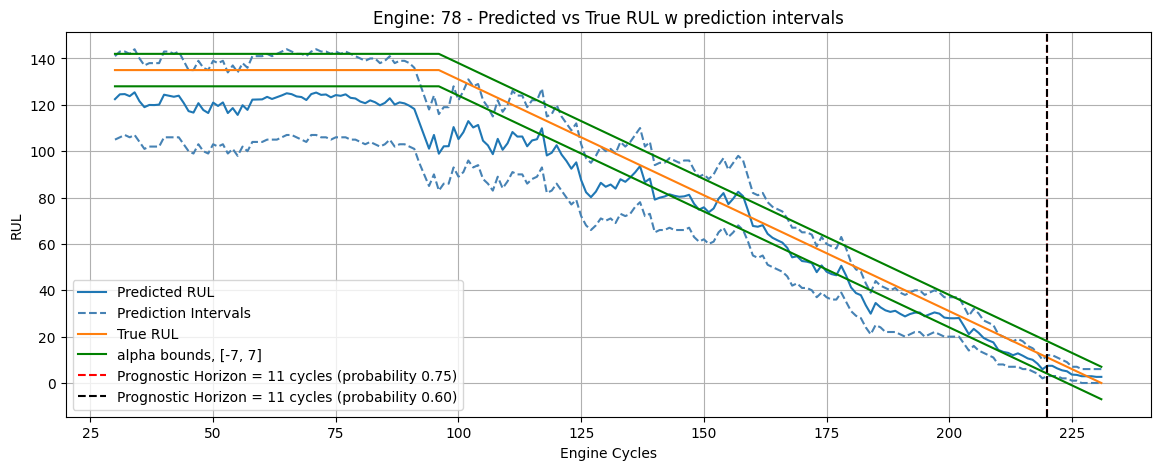

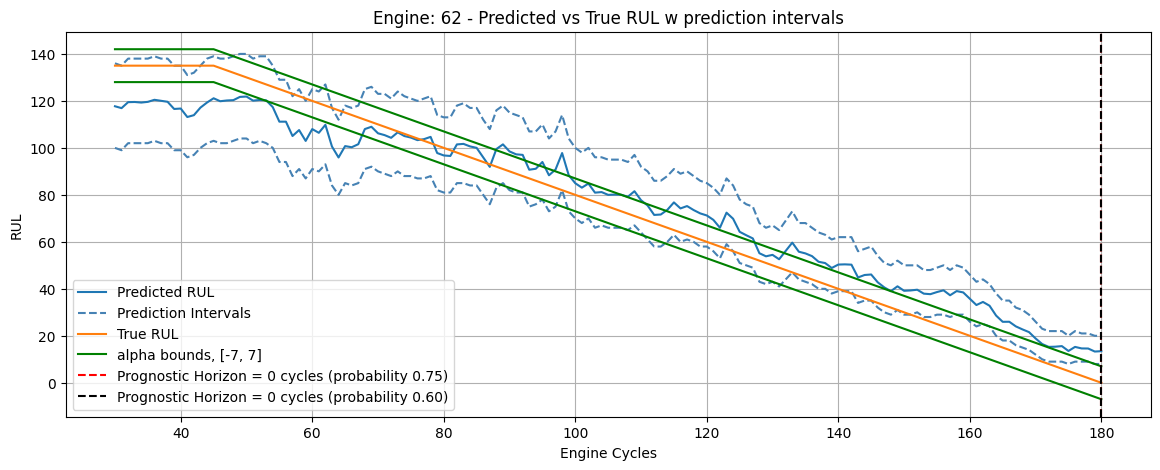

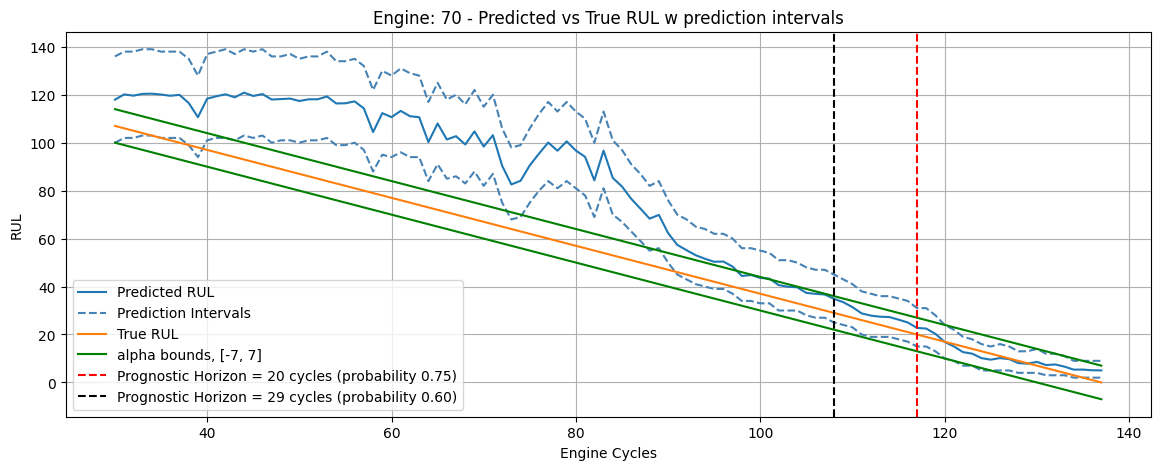

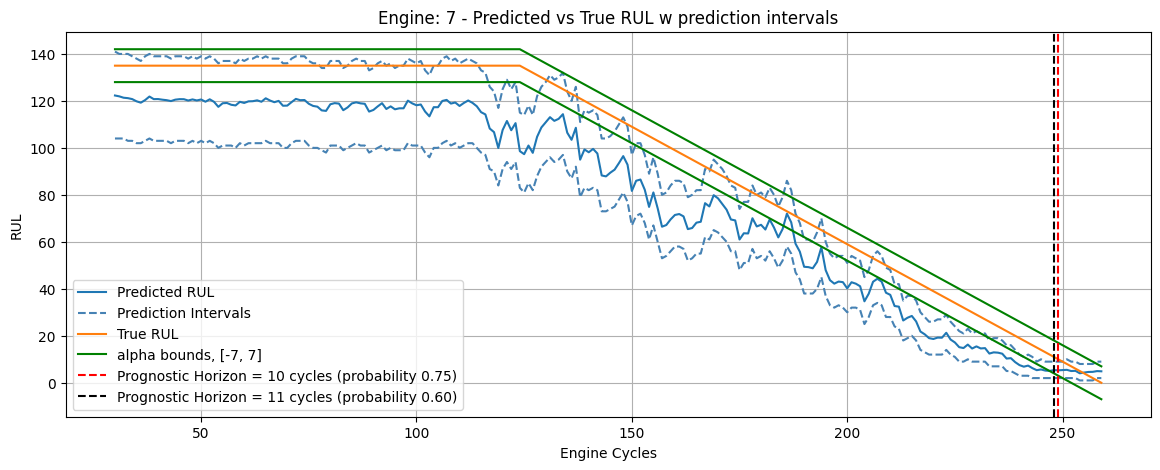

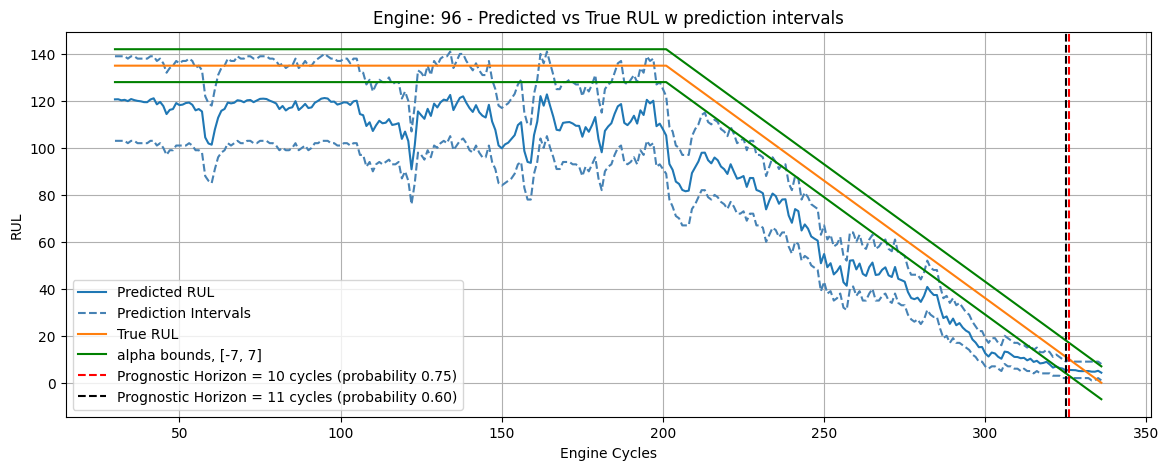

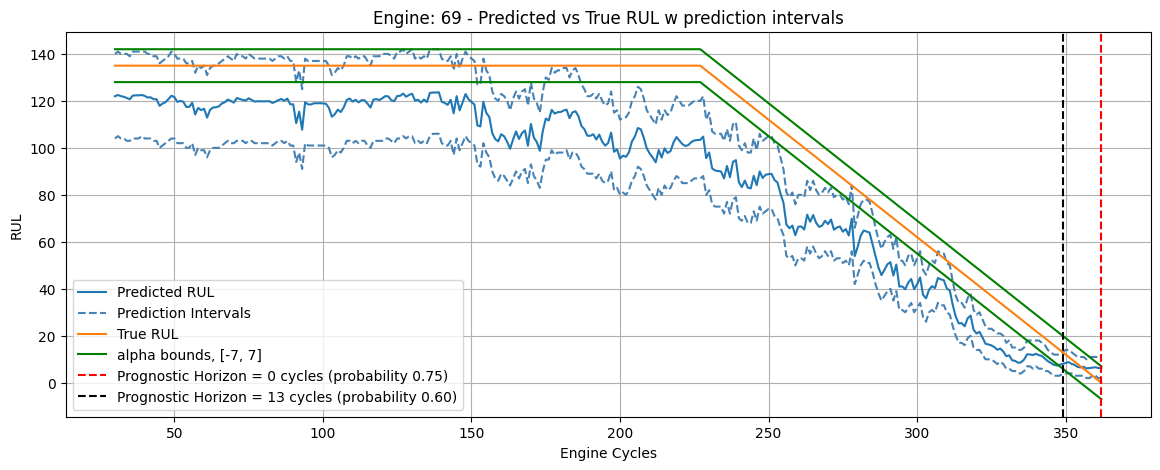

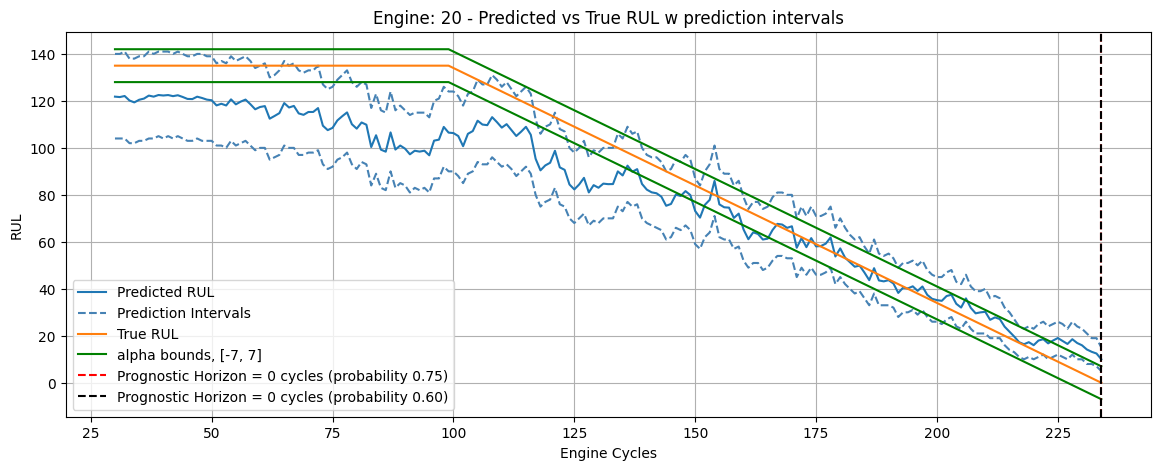

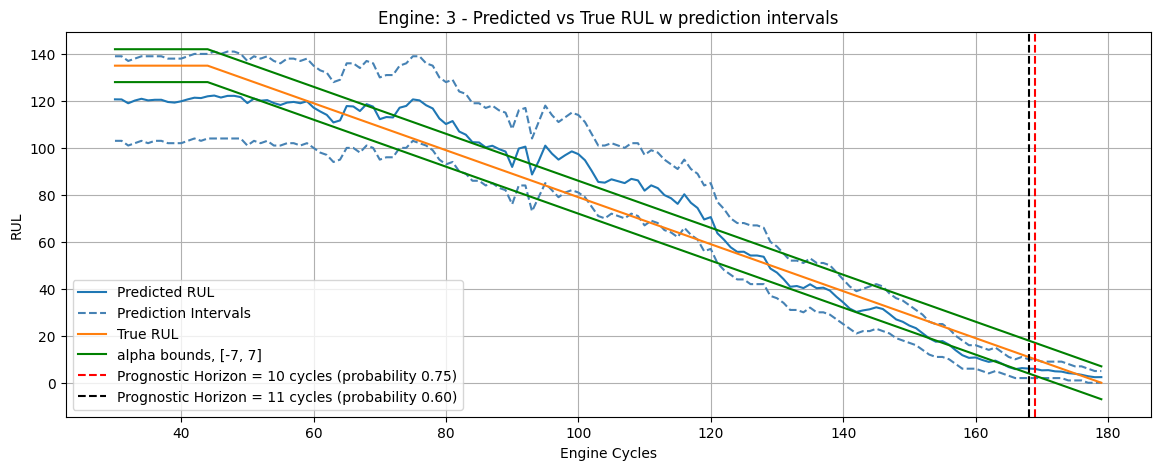

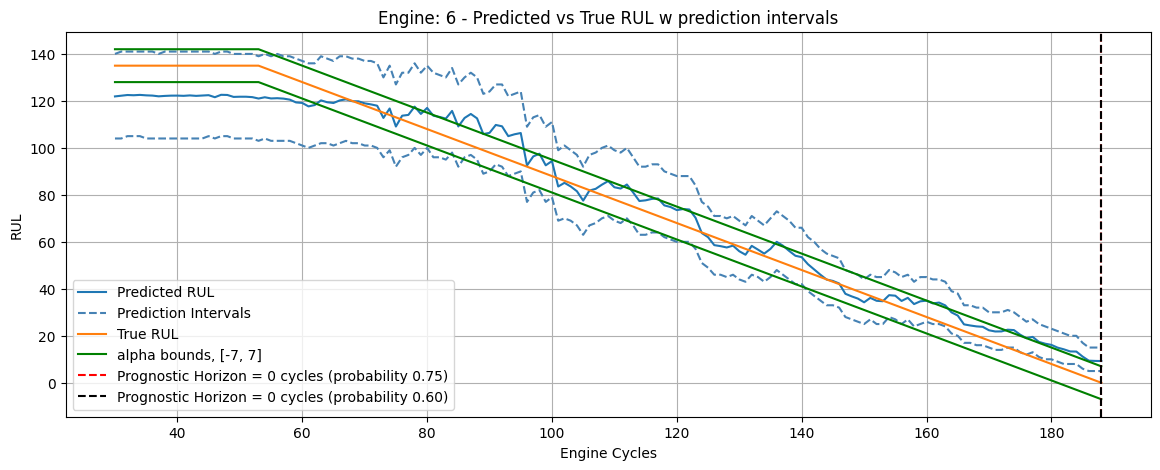

In [72]:
import pandas as pd

pr_hoziron_df = pd.DataFrame()

for val_unit in validation_units:
    val_unit_df = X_train[train_units_df["unit"] == val_unit]
    val_unit_rul = calculate_RUL(
        train_units_df[train_units_df["unit"] == val_unit], upper_threshold=135
    )

    predicted_rul = ngb.predict(val_unit_df[SELECTED_FEATURES].values)
    predicted_dist = ngb.pred_dist(val_unit_df[SELECTED_FEATURES].values)

    alphas = [-7, 7]
    pr_horizon_75, _ = prognostic_horizon(
        predicted_dist, val_unit_rul, beta=0.75, alphas=alphas
    )
    pr_horizon_60, _ = prognostic_horizon(
        predicted_dist, val_unit_rul, beta=0.60, alphas=alphas
    )

    # Replace append with concat
    pr_hoziron_df = pd.concat(
        [
            pr_hoziron_df,
            pd.DataFrame(
                [
                    {
                        "unit": val_unit,
                        "prognostic_horizon": pr_horizon_75,
                        "probability": 0.75,
                        "alpha": alphas,
                    },
                    {
                        "unit": val_unit,
                        "prognostic_horizon": pr_horizon_60,
                        "probability": 0.60,
                        "alpha": alphas,
                    },
                ]
            ),
        ],
        ignore_index=True,
    )

    plt.figure(figsize=(14, 5))
    plt.plot(val_unit_df["time_cycles"], predicted_rul, label="Predicted RUL")
    plt.plot(
        val_unit_df["time_cycles"],
        predicted_dist.dist.ppf(0.95),
        linestyle="--",
        color="steelblue",
        label="Prediction Intervals",
    )
    plt.plot(
        val_unit_df["time_cycles"],
        predicted_dist.dist.ppf(0.05),
        linestyle="--",
        color="steelblue",
    )
    plt.plot(val_unit_df["time_cycles"], val_unit_rul, label="True RUL")
    plt.plot(
        val_unit_df["time_cycles"],
        val_unit_rul + alphas[1],
        color="green",
        label=f"alpha bounds, {alphas}",
    )
    plt.plot(val_unit_df["time_cycles"], val_unit_rul + alphas[0], color="green")

    plt.axvline(
        x=val_unit_df["time_cycles"].values[::-1][pr_horizon_75],
        color="red",
        linestyle="--",
        label=f"Prognostic Horizon = {pr_horizon_75} cycles (probability 0.75)",
    )
    plt.axvline(
        x=val_unit_df["time_cycles"].values[::-1][pr_horizon_60],
        color="black",
        linestyle="--",
        label=f"Prognostic Horizon = {pr_horizon_60} cycles (probability 0.60)",
    )

    plt.legend()
    plt.grid()
    plt.title(f"Engine: {int(val_unit)} - Predicted vs True RUL w prediction intervals")
    plt.ylabel("RUL")
    plt.xlabel("Engine Cycles")
    plt.show()